In [16]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import cooling

save_path = "./data" # Set this to wherever you want output files written

## Example cooling notebook

In this example notebook we show how to set up and run cooling simulations, with the user specifying the model, noise, and cooling protocol. Below we demonstrate cooling in the 2D Ising model as an example. 

Set up of cooling simulations typically follows the following pipeline:

  1. Define lattice geometry and qubit device
  2. Build Hamiltonian (+ noise model, optionally)
  3. Build cooling protocol (or a cooling schedule with finer-grained control)
  4. Run the simulation (statevector trajectories)
  5. Load and inspect results


#### First we setup the system lattice and device (including the bath qubits):

Several default lattices are found in the <span style="color:red">cooling/lattices</span> folder. Below we setup a square lattice in 2D. Next we define a "CoolingDevice" which converts the lattice data into a Cirq qubit layout, and specifies the bath qubits (here we do not impose a fixed geometry on the bath qubits). A CoolingDevice can also be initialised from a Cirq Device directly, in which case the system/bath qubits must be explicitly set. We can visualise the lattice via the device.draw method. 

Text(0.5, 1.0, '2D square lattice (PBC)')

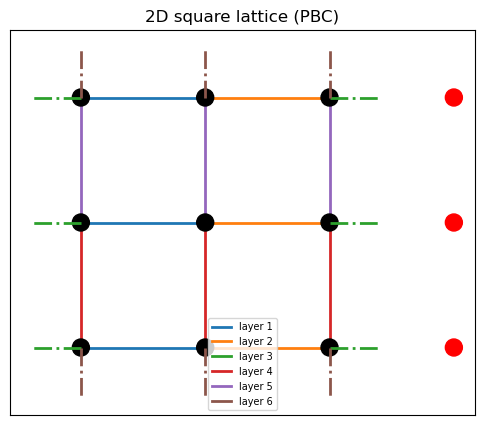

In [17]:
# ---------------------------------------------------------------------------
# 1. Lattice & device
# ---------------------------------------------------------------------------
lattice = cooling.SquareLattice2D(Lx=3, Ly=3, pbc_x=True, pbc_y=True) # 3x3 lattice with PBC in both directions
Nb = 3  # 3 bath qubits
device = cooling.CoolingDevice.from_lattice(lattice, Nb=Nb) # initialise CoolingDevice from lattice

fig, ax = plt.subplots(1,1, figsize=(6,5))

device.draw(ax=ax) # visualise the device (layers correspond to commuting bond layers)
ax.set_title("2D square lattice (PBC)")

#### Now define the model, here the 2D quantum Ising model:

We take the mixed-field Ising model:
$$ H = J\sum_{\langle i,j\rangle} X_iX_j -  g \sum_i Z_i  -  g_x \sum_i X_i, $$
where the first sum runs over nearest-neighbours defined by the lattice. The model is initialised from the device and a set of model parameters passed as a dictionary. Other models are defined in the <span style="color:red">cooling/models</span> folder.

In [18]:
# ---------------------------------------------------------------------------
# 2. Hamiltonian  H = J Σ XX - g Σ Z - gx Σ X
# ---------------------------------------------------------------------------
model_params = {"J": 0.2, "g": 1.0, "gx": 0.0}
model = cooling.IsingModel(device, model_params)
# model.draw_model() # visualise the model via Floquet circuit

#### Define the cooling channel/protocol & noise model. 

The cooling protocol is the channel applied at each step of the protocol. More complicated time-dependence where the channel or channel parameters change at each reset step can be incorporated using the Schedule approach, see below. Here we use the detailed balance protocol (https://arxiv.org/abs/2506.21318) which drives the system to a thermal state at inverse temperature $\beta$. The protocol uses either a gaussian filter function or the "modulated coupling" filter for ground state preparation. The Hamiltonian evolution is implemented via first or second order Trotterization. The bath qubits evolve under the Zeeman splitting $H_B = -h/2 \sum_\mu Z_\mu $. Other protocols are defined in the <span style="color:red">cooling/protocols</span> folder.

We also define a noise model which is applied to the circuit during evolution. Here we choose a basic noise model which applies depolarizing noise after every one and two qubit gate with strength $p_1 = 0.1\times  p_2$ and $p_2$ respectively. We can also include reset errors. Noise models are defined in the <span style="color:red">cooling/noise</span> folder.

In [19]:
# ---------------------------------------------------------------------------
# 3. Depolarizing noise model and detailed balance protocol
# ---------------------------------------------------------------------------
p2 = 1e-4 # depolarizing noise strength
noise_params = {"p1": p2 / 10, "p2": p2, "p_reset": 0.0}
noise = cooling.BasicNoiseModel(device, noise_params)

# define protocol params: 
# inverse temperature, Trotter angle, bath field, system-bath coupling, filter function truncation
protocol_params = {"beta": 1.0, "delta": 0.1, "h": 4.0, "theta": 1.0, "NT": 2}

protocol = cooling.DetailedBalanceProtocol(
    device, model,
    params=protocol_params,
    function="gaussian",
    trotter_order=1,
    noise_model=noise,
)

coupling_geometry={k:k for k in range(Nb)} # standard coupling geometry to determine gate count
gates = protocol.channel_depth(coupling_geometry, compile=False) # print gate count for single channel application

single gate merging -- removed 9 gates
drop negligible operations -- removed 0 gates
Circuit depth (moments): 177
Total gates: 729
2-qubit gates: 462


#### Set up the simulator and run trajectories

Having defined the protocol we can set up the Cirq simulator and simulate the cooling dynamics. The simulation is carried out via statevector Monte Carlo, i.e. a single Kraus operator defined by the channel is randomly sampled (according to the Born probability distribution) and applied to the wavefunction. Simulation routines are defined in <span style="color:red">cooling/simulation.py</span>.

The most basic way to run the simulator is by repeatedly applying the cooling protocol channel with fixed parameters. By default, the simulation uses a measurement routine which measures the Hamiltonian energy and total spin operators at each reset step (other measurement routines can be defined in the cooling/measurements folder).

In [20]:
# ---------------------------------------------------------------------------
# 4. Basic simulation
# ---------------------------------------------------------------------------

ops  = ['X', 'Y', 'Z']
coupling_ops      = {k: str(np.random.choice(ops)) for k in range(Nb)} # random Pauli ops for coupling
coupling_geometry = {k:k for k in range(Nb)} # define a system-bath coupling geometry
circuit = protocol.channel(coupling_geometry, coupling_ops)   # fixed cooling channel applied each reset

sim = cooling.Simulation(protocol) # initialise simulator
R, K = 20, 1 # number of resets, number of trajectories
record = sim.run(circuit, R=R, K=K, seed=1, overwrite=True) # run trajectory simulations
print(record)

    repeat   t        H0   total_Z       total_X       total_Y   total_S2
0        0   0 -3.000000  1.500000  0.000000e+00  0.000000e+00   6.750000
1        0   1 -1.562261  0.684608 -3.728292e-06  3.889987e-06   4.136931
2        0   2 -2.985863  1.354653 -2.433939e-08  2.570173e-06   5.037858
3        0   3 -3.061865  1.445732 -1.324444e-06  1.159645e-06   4.788607
4        0   4 -3.072134  1.466103 -6.269819e-07  2.048542e-06   5.217279
5        0   5 -3.165807  1.480522 -6.893683e-07  6.474370e-07   5.972317
6        0   6 -3.229049  1.483142 -5.104825e-07  1.226978e-06   5.499883
7        0   7 -3.928364  1.811280 -1.028163e-06  1.546340e-06   7.342646
8        0   8 -3.680278  1.634787 -6.612796e-07  1.818871e-06   6.211203
9        0   9 -4.163151  1.800648 -6.638288e-07  7.501532e-07   7.534391
10       0  10 -4.689090  2.075379 -1.144814e-06  1.698340e-06   8.481223
11       0  11 -5.745956  2.687147 -1.114705e-06  2.427520e-06  12.202982
12       0  12 -6.294421  2.887525 -7.

#### Define a randomized scheduler

The basic simulation above applies the same reset channel many times. It is helpful (for mixing purposes) to include some randomized features in the dynamics. Here, we define a "schedule" which allows the coupling geometry (which system qubits couple to which bath qubits) and the coupling operators to be randomly selected at the start of each new reset cycle. Ideally the circuit would be uniformly randomly sampled at the start of each cycle. To speed up the statevector simulations however, it is better to hold a fixed cache of $M$ random circuits in memory rather than randomly redrawing a circuit every step, and sample from this fixed set. In practice $M\sim 30$ seems sufficient at accessible system sizes (and experiment would just randomize at every cycle). Other schedules (e.g. annealed schedules) can be added in the <span style="color:red">cooling/schedules</span> folder.

We then define the Circ simulator from the scheduler as well as the protocol (see <span style="color:red">cooling/simulation.py</span>). We can also run multiple trajectories in parallel using the run_parallel method.

In [22]:
# ---------------------------------------------------------------------------
# 5. Randomized schedule simulation
# ---------------------------------------------------------------------------
import time

# allowed ops sets the possible coupling operators, randomly chosen for each cached circuit
sched = cooling.Randomized(protocol, n_cache=30, seed=1, allowed_ops=["X", "Y", "Z"])
sim = cooling.Simulation(protocol)

R = 50
K = 30
t0 = time.perf_counter()
record = sim.run_parallel(sched, R=R, K=K, tag=f"test", n_workers=4, save_path=save_path, overwrite=True) # run using 4 parallel workers
t_seq = time.perf_counter()-t0
print(f"n_workers={4}: {t_seq:.1f}s  ({t_seq/K:.2f} per trajectory)")


n_workers=4: 19.5s  (0.65 per trajectory)


#### Inspect results

We can load and inspect the aggregated trajectory data. To assess cooling accuracy, we can compare to results from exact diagonalisation (implemented using the QuSpin package). For larger systems we will need to resort to other metrics.

loading pre-computed energies IsingModel_square2D_Lx3Ly3PxPy_J0.200_g1.000_gx0.000_Spec
Steady-state energy: -6.6362
Thermal energy (ED): -7.0764
Relative error:      0.0622


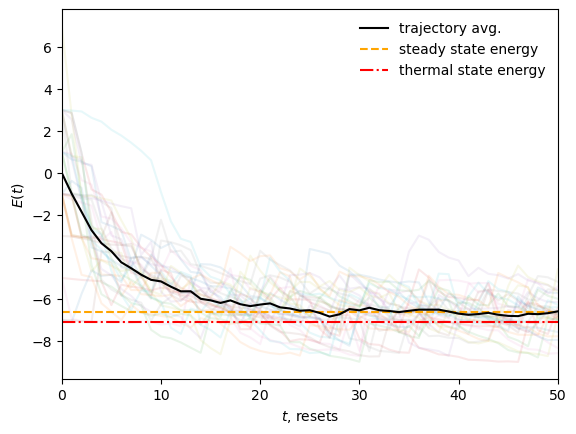

In [23]:
# ---------------------------------------------------------------------------
# 5. Load and inspect results
# ---------------------------------------------------------------------------

record = sim.load(sched, R=R, K=K, tag="test", save_path=save_path)
obs_cols = [c for c in record.columns if c not in ("repeat", "t")]
mean = record.groupby("t")[obs_cols].mean() # average over trajectories
x    = mean.index

fig, ax = plt.subplots()
ax.plot(x, mean["H0"], lw=1.5, color='k', zorder=10, label=r'trajectory avg.')
for r, g in record.groupby("repeat"):
    ax.plot(g["t"], g["H0"], alpha=0.1)

ax.set_xlim(0, 50)
ax.set_xlabel(r'$t$, resets')
ax.set_ylabel(r'$E(t)$')

# Compute steady-state energy (average over last half of trajectory here)
mean_E = record.groupby("t")["H0"].mean()
e_ss = mean_E.loc[mean_E.index >= mean_E.index.max() // 2].mean()

ax.axhline(e_ss, ls='--', color='orange', label='steady state energy')

# Compare to exact thermal energy via ED (requires quspin)
_, e_thermal = cooling.ThermalEnergy(model, beta=protocol_params['beta'])
ax.axhline(e_thermal, ls='-.', color='red', label='thermal state energy')
ax.legend(frameon=False)

rel_err = abs(e_ss - e_thermal) / abs(e_thermal)
print(f"Steady-state energy: {e_ss:.4f}")
print(f"Thermal energy (ED): {e_thermal:.4f}")
print(f"Relative error:      {rel_err:.4f}")



#### Putting everything together

Compare noisy ($p=10^{-3}$) and noiseless cooling for 3x4 Ising model.

n_workers=4: 154.3s  (5.14 per trajectory)
n_workers=4: 128.1s  (4.27 per trajectory)
calculating new energies IsingModel_square2D_Lx4Ly3PxPy_J0.200_g1.000_gx0.000_Spec
  translation symmetry (x) found
  translation symmetry (y) found
  parity skipped: incompatible with translation symmetry on PBC lattice
  Z2 spin-inversion symmetry found (Hadamard rotation: Z->X)


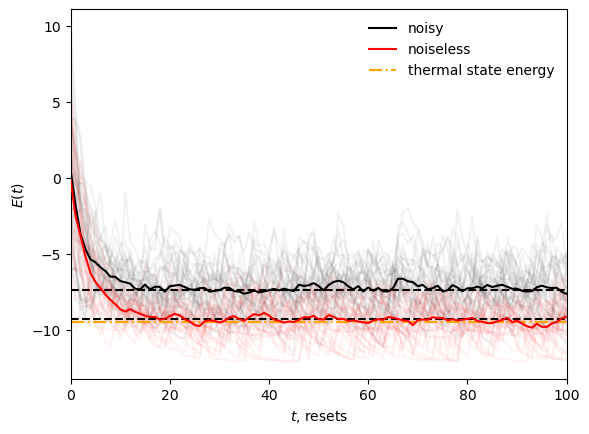

In [14]:
# ---------------------------------------------------------------------------
# 3x4 Ising model, 6 bath qubits
# ---------------------------------------------------------------------------

lattice = cooling.SquareLattice2D(Lx=4, Ly=3, pbc_x=True, pbc_y=True) 
Nb = 6
device = cooling.CoolingDevice.from_lattice(lattice, Nb=Nb) 

model_params = {"J": 0.2, "g": 1.0, "gx": 0.0}
model = cooling.IsingModel(device, model_params)

# ---------------------------------------------------------------------------
# Noisy protocol
# ---------------------------------------------------------------------------
R = 200
K = 30

p2 = 1e-3 # depolarizing noise strength
noise_params = {"p1": p2 / 10, "p2": p2, "p_reset": 0.0}
noise = cooling.BasicNoiseModel(device, noise_params)
protocol_params = {"beta": 1.0, "delta": 0.1, "h": 4.0, "theta": 1.0, "NT": 2}

protocol_noisy = cooling.DetailedBalanceProtocol(
    device, model,
    params=protocol_params,
    function="gaussian",
    trotter_order=1,
    noise_model=noise,
)

sched_noisy = cooling.Randomized(protocol_noisy, n_cache=30, seed=1, allowed_ops=["X", "Y", "Z"])
sim_noisy = cooling.Simulation(protocol_noisy)


t0 = time.perf_counter()
record_noisy = sim_noisy.run_parallel(sched_noisy, R=R, K=K, tag=f"noisy_test", n_workers=4, save_path=save_path, overwrite=True)
t_seq = time.perf_counter()-t0
print(f"n_workers={4}: {t_seq:.1f}s  ({t_seq/K:.2f} per trajectory)")

# ---------------------------------------------------------------------------
# Noiseless protocol
# ---------------------------------------------------------------------------

protocol_params = {"beta": 1.0, "delta": 0.1, "h": 4.0, "theta": 1., "NT": 2}

protocol_noiseless = cooling.DetailedBalanceProtocol(
    device, model,
    params=protocol_params,
    function="gaussian",
    trotter_order=1,
    noise_model=None,
)

sched_noiseless = cooling.Randomized(protocol_noiseless, n_cache=30, seed=1, allowed_ops=["X", "Y", "Z"])
sim_noiseless = cooling.Simulation(protocol_noiseless)


t0 = time.perf_counter()
record_noiseless = sim_noiseless.run_parallel(sched_noiseless, R=R, K=K, tag=f"noiseless_test", n_workers=4, save_path=save_path, overwrite=True)
t_seq = time.perf_counter()-t0
print(f"n_workers={4}: {t_seq:.1f}s  ({t_seq/K:.2f} per trajectory)")

# ---------------------------------------------------------------------------
# Plot results
# ---------------------------------------------------------------------------

fig, ax = plt.subplots()

obs_cols = [c for c in record_noisy.columns if c not in ("repeat", "t")]
mean = record_noisy.groupby("t")[obs_cols].mean() # average over trajectories
x    = mean.index
ax.plot(x, mean["H0"], lw=1.5, color='k', zorder=10, label=r'noisy')
for r, g in record_noisy.groupby("repeat"):
    ax.plot(g["t"], g["H0"], alpha=0.05, color='k')

mean_E = record_noisy.groupby("t")["H0"].mean()
e_ss_noisy = mean_E.loc[mean_E.index >= mean_E.index.max() // 2].mean()
ax.axhline(e_ss_noisy, ls='--', color='k')

obs_cols = [c for c in record_noiseless.columns if c not in ("repeat", "t")]
mean = record_noiseless.groupby("t")[obs_cols].mean() # average over trajectories
x    = mean.index
ax.plot(x, mean["H0"], lw=1.5, color='r', zorder=10, label=r'noiseless')
for r, g in record_noiseless.groupby("repeat"):
    ax.plot(g["t"], g["H0"], alpha=0.05, color='r')

mean_E = record_noiseless.groupby("t")["H0"].mean()
e_ss_noiseless = mean_E.loc[mean_E.index >= mean_E.index.max() // 2].mean()
ax.axhline(e_ss_noiseless, ls='--', color='k')

_, e_thermal = cooling.ThermalEnergy(model, beta=protocol_params['beta'])
ax.axhline(e_thermal, ls='-.', color='orange', label='thermal state energy')

ax.set_xlim(0, 100)
ax.set_xlabel(r'$t$, resets')
ax.set_ylabel(r'$E(t)$')
ax.legend(frameon=False)

